In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

data_file = "data_MPG.csv"

In [34]:
df = pd.read_csv(data_file)
# print(df.sample(5))
print(df.head(5))


    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


Great — you’re looking at a subset of the **MPG dataset** (Auto MPG dataset from the UCI Machine Learning Repository). This dataset is widely used in data science and machine learning for regression and exploratory data analysis (EDA). Let me break down what each column means:

---

### Columns in the dataset:

1. **mpg**

   * Miles per gallon → the fuel efficiency of the car.
   * Higher values = better fuel economy.
   * This is usually treated as the **target variable** in regression tasks.

2. **cylinders**

   * Number of engine cylinders.
   * Common values: 3, 4, 5, 6, 8.
   * Higher cylinders generally mean more power but worse fuel economy.

3. **displacement**

   * Engine displacement in cubic inches (ci).
   * Larger displacement = larger engine size.
   * Typically correlates with horsepower and weight.

4. **horsepower**

   * Horsepower of the car (engine power).
   * Higher horsepower = faster acceleration, lower mpg usually.

5. **weight**

   * Vehicle weight (in pounds).
   * Heavier cars generally consume more fuel (lower mpg).

6. **acceleration**

   * Time taken to go from 0 to 60 mph (in seconds).
   * Lower values = faster acceleration.
   * Influenced by horsepower and weight.

7. **model\_year**

   * Last two digits of the car’s model year (70 = 1970, 81 = 1981).
   * Useful for observing trends over time (fuel efficiency improved in later years).

8. **origin**

   * Region where the car was manufactured:

     * 1 or `"usa"` → American cars
     * 2 or `"europe"` → European cars
     * 3 or `"japan"` → Japanese cars
   * Often used to compare car design philosophies across regions.

9. **name**

   * The full car name (make + model).
   * Example: `"ford thunderbird"`, `"mazda 626"`.

---


### 4. **Multivariate Analysis**

* Pair plots between `mpg`, `weight`, `horsepower`, `displacement`, `acceleration`.
* Heatmap of correlation matrix to identify strongest relationships.
* Groupby analysis:

  * Mean mpg by `origin` and `cylinders`.
  * Mean mpg trend over years.


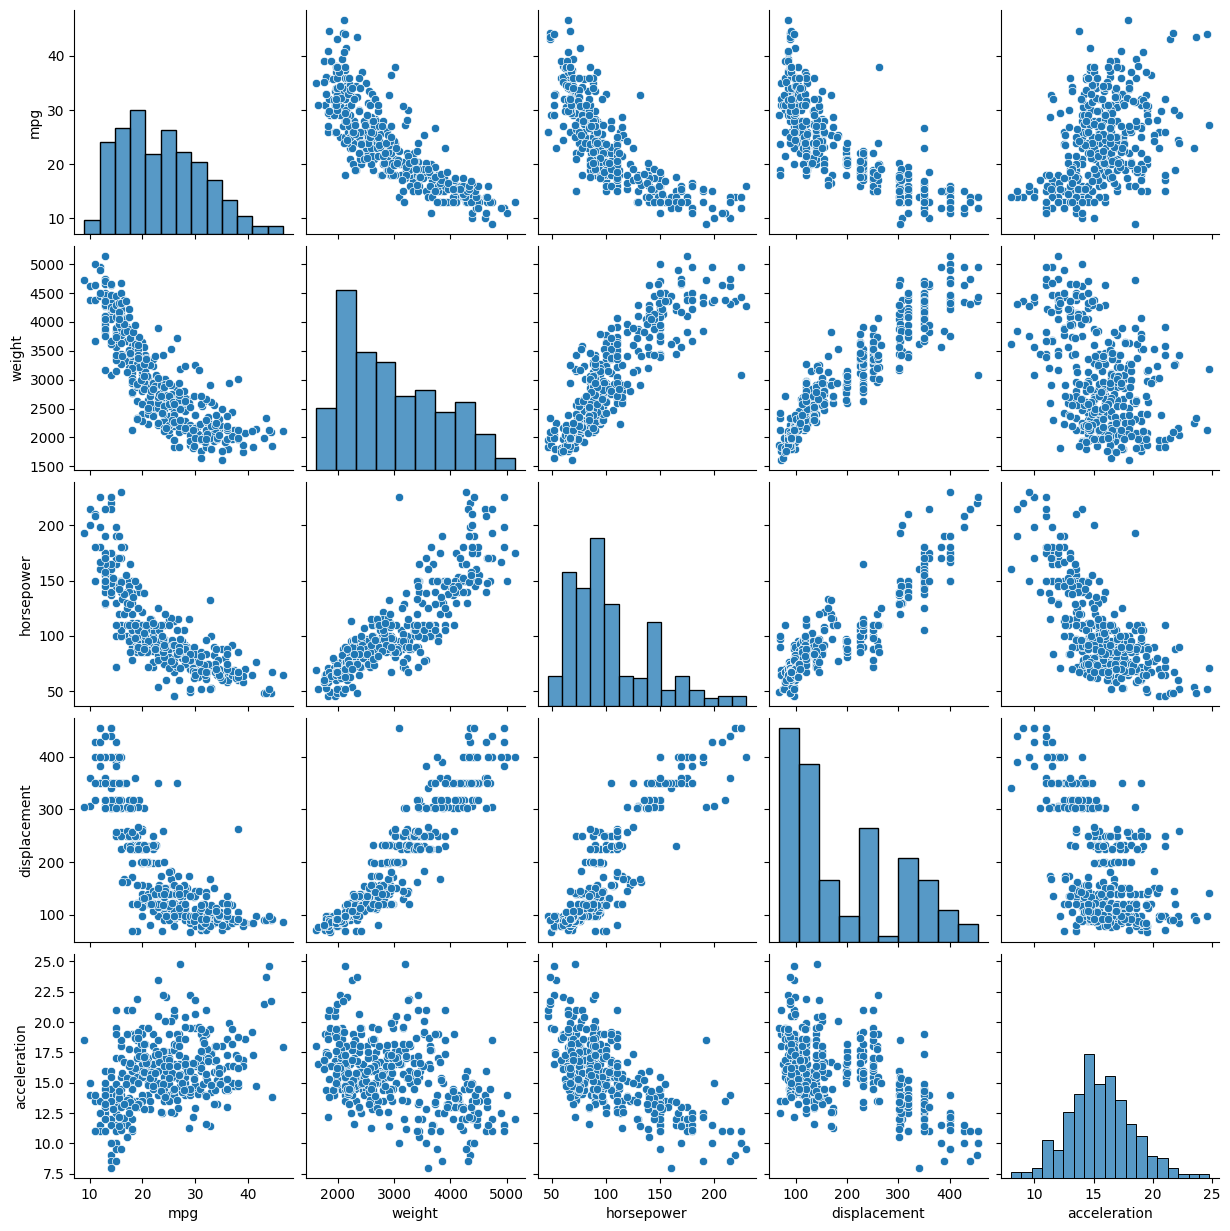

In [32]:
sns.pairplot(data=df[["mpg", "weight", "horsepower", "displacement", "acceleration"]])
plt.show()

correlation matrix:
                    mpg    weight  horsepower  displacement  acceleration
mpg           1.000000 -0.831741   -0.778427     -0.804203      0.420289
weight       -0.831741  1.000000    0.864538      0.932824     -0.417457
horsepower   -0.778427  0.864538    1.000000      0.897257     -0.689196
displacement -0.804203  0.932824    0.897257      1.000000     -0.543684
acceleration  0.420289 -0.417457   -0.689196     -0.543684      1.000000
##########




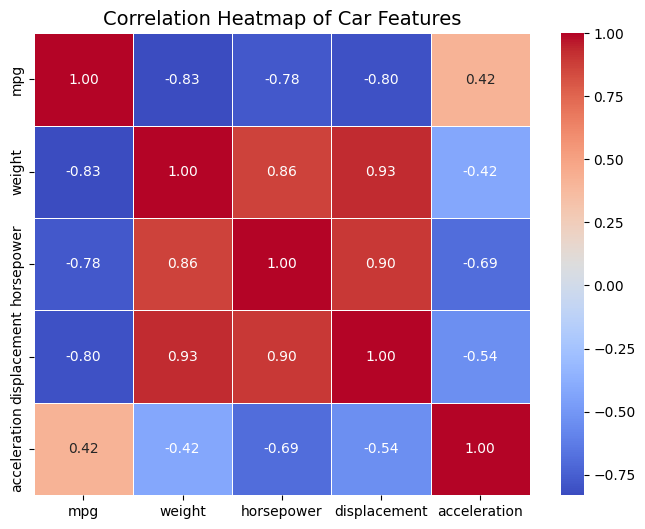

In [39]:
# Heatmap

corr_matrix = df[["mpg", "weight", "horsepower", "displacement", "acceleration"]].corr()
print("correlation matrix:\n", corr_matrix)
print("##########\n\n")
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of Car Features", fontsize=14)
plt.show()

Mean grouped value of MPG: 
 origin  cylinders
europe  4            28.411111
        5            27.366667
        6            20.100000
japan   3            20.550000
        4            31.595652
        6            23.883333
usa     4            27.840278
        6            19.663514
        8            14.963107
Name: mpg, dtype: float64
+++++++




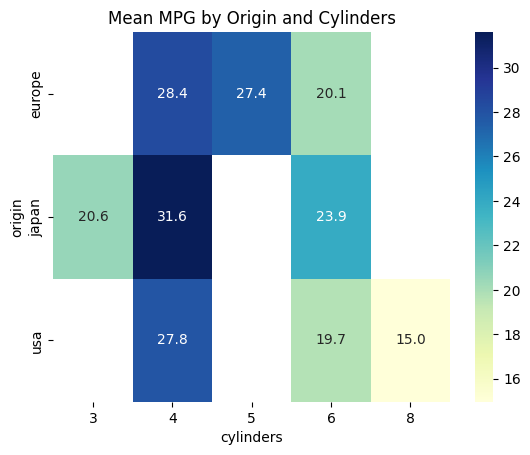

In [44]:
# Group by origin and cylinders, then take mean mpg
grouped = df.groupby(["origin", "cylinders"])["mpg"].mean()

print("Mean grouped value of MPG: \n", grouped)
print("+++++++\n\n")

pivot_table = df.pivot_table(values="mpg", index="origin", columns="cylinders", aggfunc="mean")

sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Mean MPG by Origin and Cylinders")
plt.show()

# observ: The 4 cylinder cars from Japan give good aerage of MPG

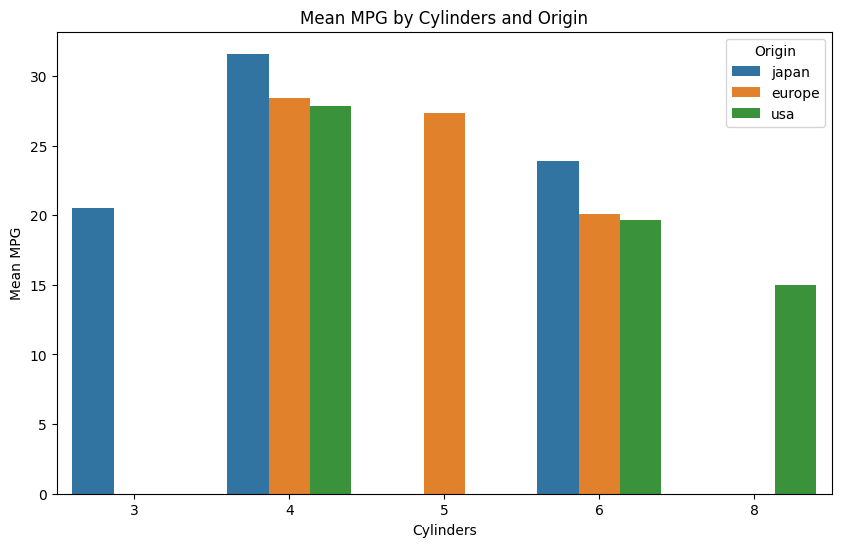

In [45]:
# grouped barplot is great for comparing mpg across cylinder counts, broken down by origin.
plt.figure(figsize=(10,6))
sns.barplot(x="cylinders", y="mpg", hue="origin", data=df, estimator="mean", errorbar=None)

plt.title("Mean MPG by Cylinders and Origin")
plt.xlabel("Cylinders")
plt.ylabel("Mean MPG")
plt.legend(title="Origin")
plt.show()

# observ: No data for 3 cyl cars from USA and Europe
# No data for 5 cyl cars from USA and Japan

### 6. **Feature Relationships**

* Regression plots of mpg with weight/horsepower.
* Compare slope for different `cylinders` groups.
* Interaction effect: cylinders + year on mpg.



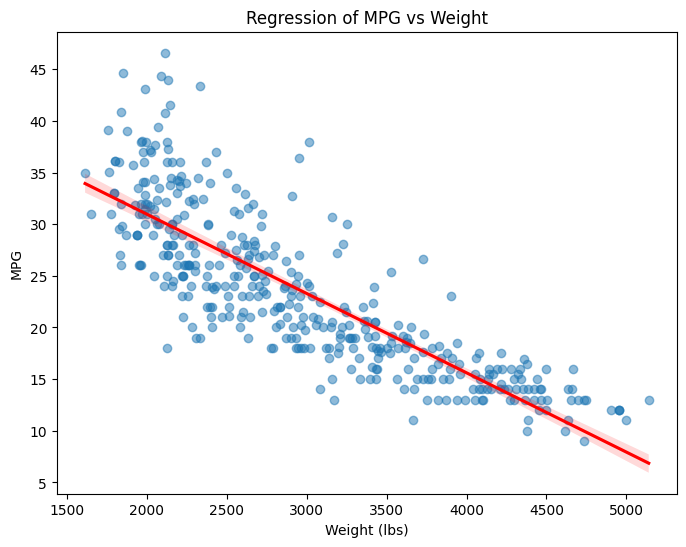

In [46]:
# Regression of MPG vs Weight

plt.figure(figsize=(8,6))
sns.regplot(x="weight", y="mpg", data=df, scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Regression of MPG vs Weight")
plt.xlabel("Weight (lbs)")
plt.ylabel("MPG")
plt.show()

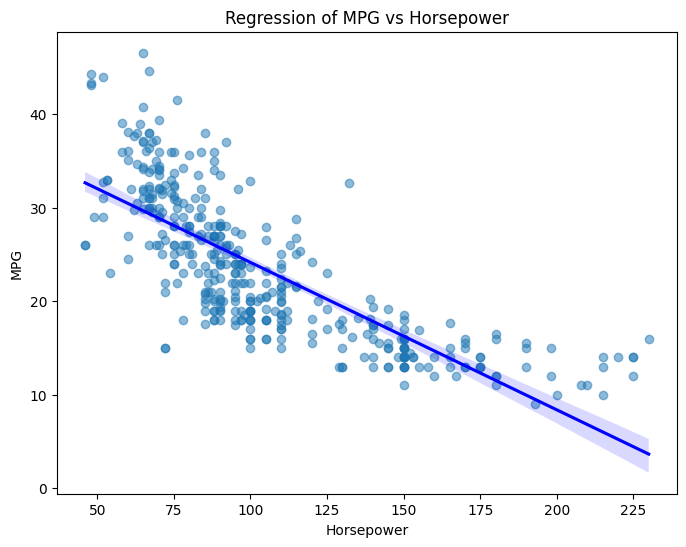

In [47]:
# Regression of MPG vs Horsepower
plt.figure(figsize=(8,6))
sns.regplot(x="horsepower", y="mpg", data=df, scatter_kws={"alpha":0.5}, line_kws={"color":"blue"})
plt.title("Regression of MPG vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()


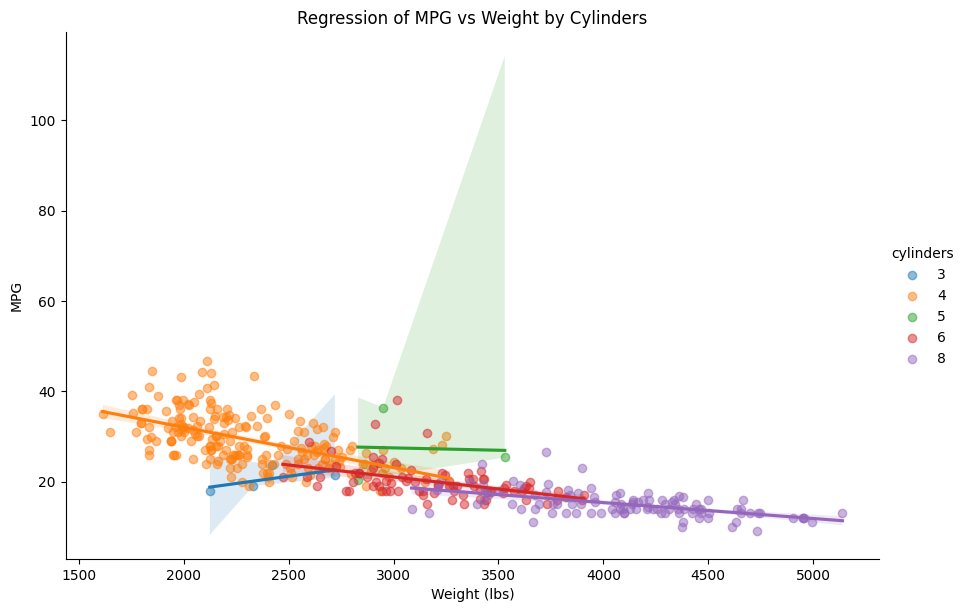

In [49]:
# Following not very helpful
# Compare MPG vs Weight slopes across cylinders

# Regression with separate slopes for each cylinder group
sns.lmplot(x="weight", y="mpg", hue="cylinders", data=df,
           aspect=1.5, height=6, scatter_kws={"alpha":0.5})

plt.title("Regression of MPG vs Weight by Cylinders")
plt.xlabel("Weight (lbs)")
plt.ylabel("MPG")
plt.show()


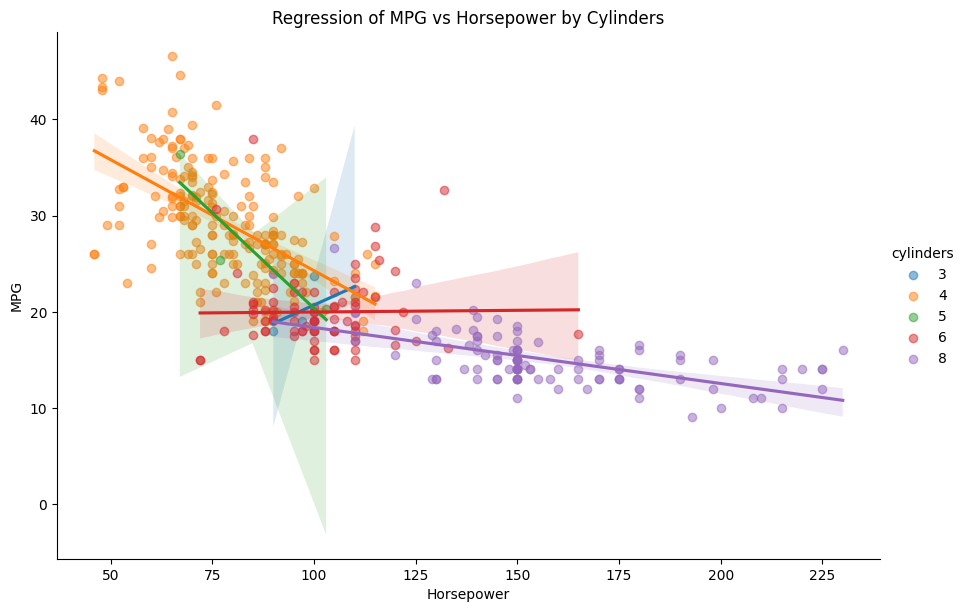

In [50]:
# Following not helpful:

sns.lmplot(x="horsepower", y="mpg", hue="cylinders", data=df,
           aspect=1.5, height=6, scatter_kws={"alpha":0.5})

plt.title("Regression of MPG vs Horsepower by Cylinders")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()


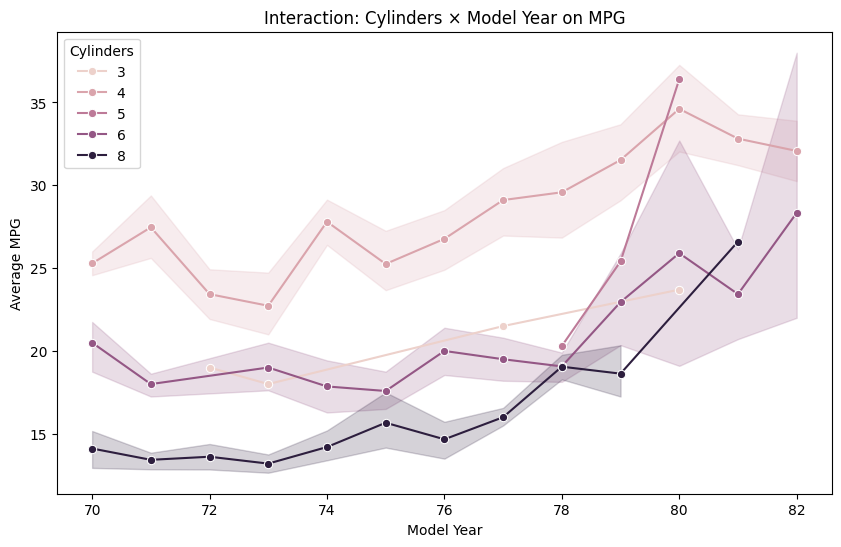

In [51]:
# step1: Interaction: Cylinders × Model Year on MPG
plt.figure(figsize=(10,6))
sns.lineplot(x="model_year", y="mpg", hue="cylinders", data=df, estimator="mean", marker="o")

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

# Some values are overlapping....giving me headache...

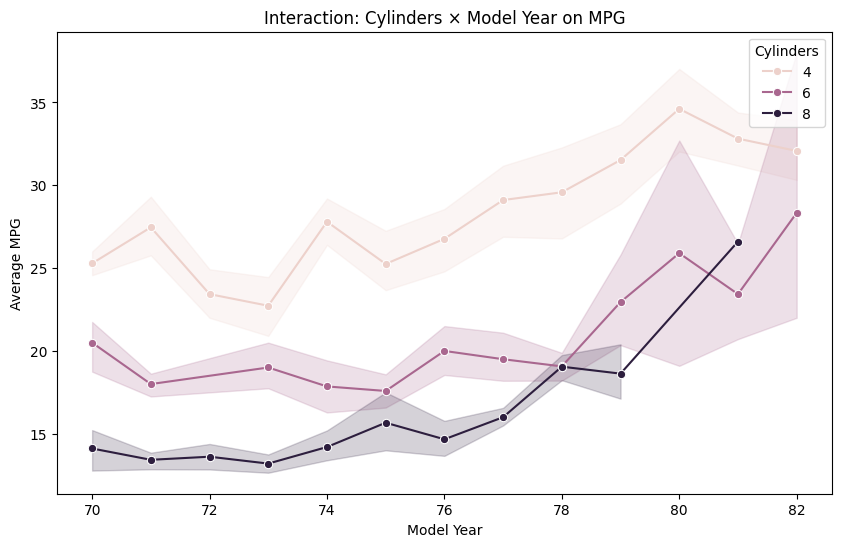

In [53]:
# step2: Perform filtering. Do only those that are visible with cylinder 4, 6, 8
mask = (df["cylinders"] == 8) | (df["cylinders"] == 6) | (df["cylinders"] == 4)

plt.figure(figsize=(10,6))
sns.lineplot(x="model_year", y="mpg", hue="cylinders", data=df[mask], estimator="mean", marker="o")

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

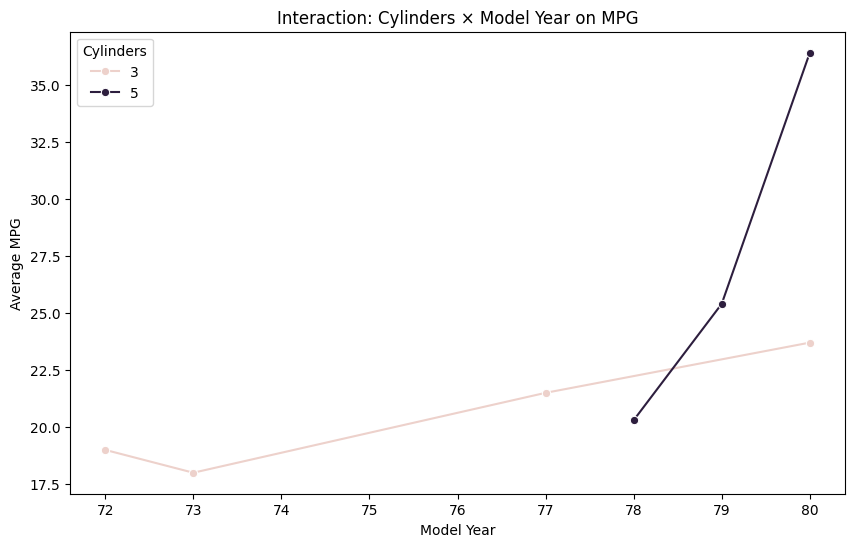

In [54]:
# step3: Perform filtering. Lets do the remaining ones with cylinder 3 and 5
mask = (df["cylinders"] == 3) | (df["cylinders"] == 5)

plt.figure(figsize=(10,6))
sns.lineplot(x="model_year", y="mpg", hue="cylinders", data=df[mask], estimator="mean", marker="o")

plt.title("Interaction: Cylinders × Model Year on MPG")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.legend(title="Cylinders")
plt.show()

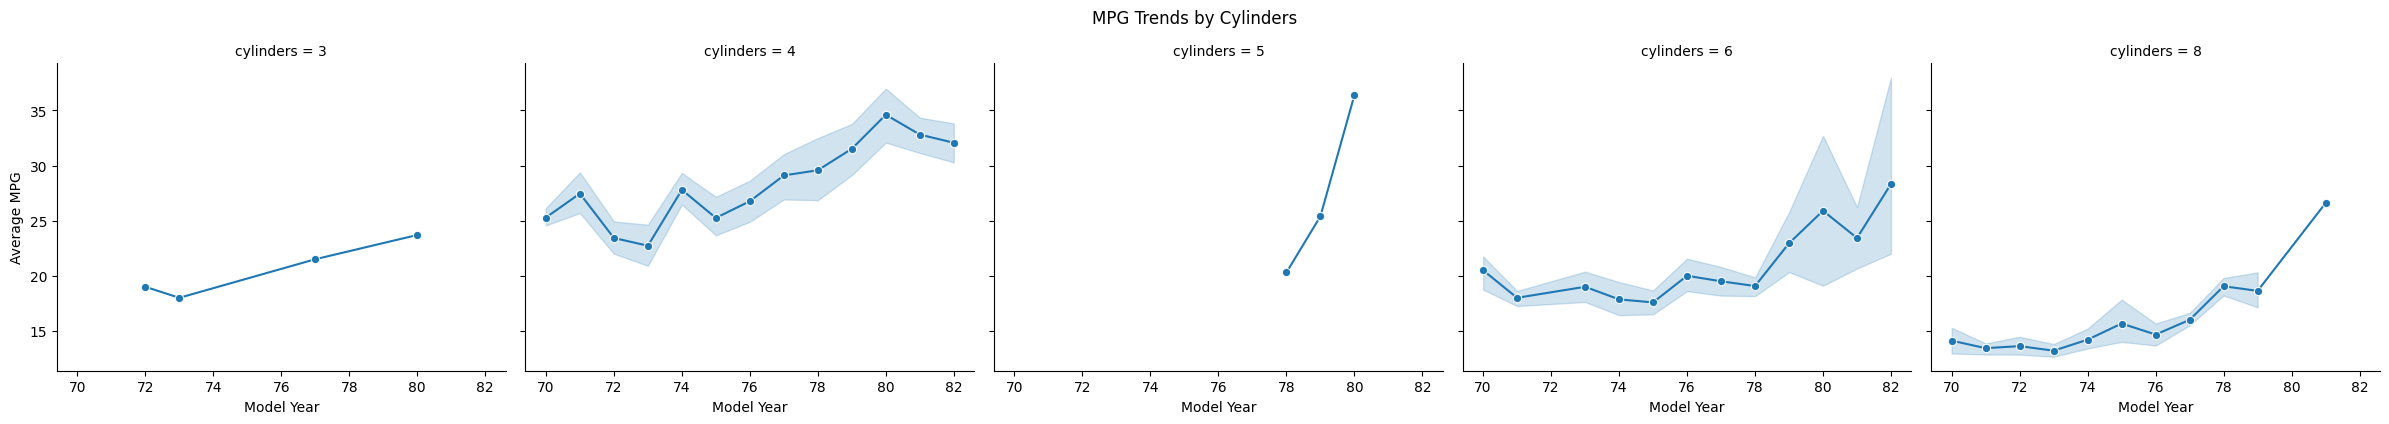

In [55]:
#step4: Lets do facetgrid
g = sns.FacetGrid(df, col="cylinders", height=4, aspect=1.2)
g.map(sns.lineplot, "model_year", "mpg", estimator="mean", marker="o")
g.set_axis_labels("Model Year", "Average MPG")
g.fig.suptitle("MPG Trends by Cylinders", y=1.05)
plt.show()

# observation: This plot is better than above.

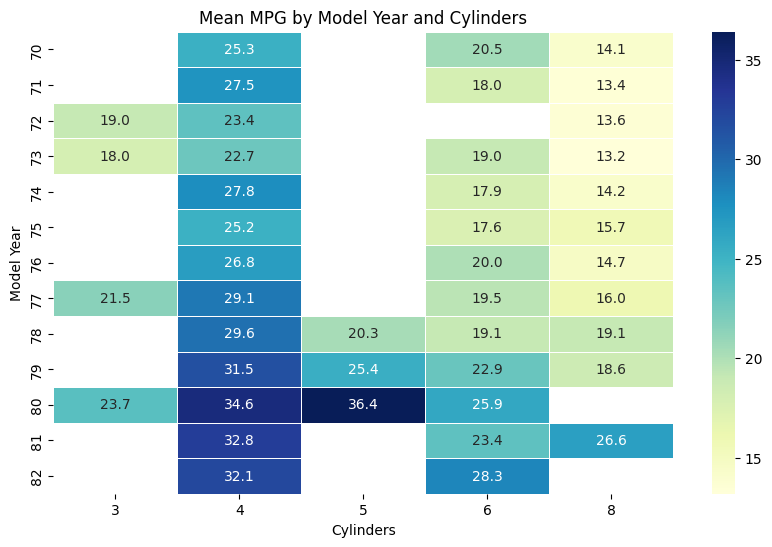

In [59]:
# Create pivot table: rows = model_year, columns = cylinders, values = mean mpg
pivot_table = df.pivot_table(values="mpg", index="model_year", columns="cylinders", aggfunc="mean")

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)

plt.title("Mean MPG by Model Year and Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("Model Year")
plt.show()

# Observ: 5cyl for 1980 gave handsome mileage